# Предсказание риска оттока клиентов
Ссылка на Kaggle: https://www.kaggle.com/datasets/abdallahwagih/telco-customer-churn.
Решение задачи классификации с дисбалансом классов. Целевая переменная – Churn Value.
## Загрузка и первичный осмотр данных

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, roc_curve
from catboost import CatBoostClassifier


ModuleNotFoundError: No module named 'src'

In [248]:
data = pd.read_excel('../data/raw/Telco_customer_churn.xlsx')
data.sample(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
4375,5578-NKCXI,1,United States,California,South Gate,90280,"33.944624, -118.192615",33.944624,-118.192615,Female,...,One year,No,Credit card (automatic),99.25,5846.65,No,0,22,4098,NaN
6004,9932-WBWIK,1,United States,California,Lake Isabella,93240,"35.607875, -118.466318",35.607875,-118.466318,Male,...,Month-to-month,No,Mailed check,20.35,215.25,No,0,46,5597,NaN
867,7657-DYEPJ,1,United States,California,Los Angeles,90024,"34.066303, -118.435479",34.066303,-118.435479,Male,...,One year,Yes,Credit card (automatic),70.15,2497.35,Yes,1,82,2645,Lack of affordable download/upload speed
586,8182-BJDSI,1,United States,California,Santa Ana,92705,"33.766004, -117.786763",33.766004,-117.786763,Female,...,Month-to-month,Yes,Electronic check,89.95,2625.55,Yes,1,90,2468,Attitude of service provider
4709,0840-DCNZE,1,United States,California,Newport Beach,92661,"33.601309, -117.902304",33.601309,-117.902304,Male,...,One year,Yes,Bank transfer (automatic),86.95,4138.9,No,0,57,5631,NaN


In [249]:
data.iloc[:, 10:30].sample(2)

,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value
5486,No,No,No,24,Yes,No,DSL,No,No,Yes,No,No,No,Month-to-month,Yes,Mailed check,49.70,1167.8,No,0
4687,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No,0


In [250]:
print(f'Размер датасета: {data.shape}')

Размер датасета: (7043, 33)


In [251]:
data.columns = data.columns.str.replace(' ', '_').str.lower()
data.columns

Index(['customerid', 'count', 'country', 'state', 'city', 'zip_code',
       'lat_long', 'latitude', 'longitude', 'gender', 'senior_citizen',
       'partner', 'dependents', 'tenure_months', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'monthly_charges', 'total_charges', 'churn_label', 'churn_value',
       'churn_score', 'cltv', 'churn_reason'],
      dtype='str')

In [252]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerid         7043 non-null   str    
 1   count              7043 non-null   int64  
 2   country            7043 non-null   str    
 3   state              7043 non-null   str    
 4   city               7043 non-null   str    
 5   zip_code           7043 non-null   int64  
 6   lat_long           7043 non-null   str    
 7   latitude           7043 non-null   float64
 8   longitude          7043 non-null   float64
 9   gender             7043 non-null   str    
 10  senior_citizen     7043 non-null   str    
 11  partner            7043 non-null   str    
 12  dependents         7043 non-null   str    
 13  tenure_months      7043 non-null   int64  
 14  phone_service      7043 non-null   str    
 15  multiple_lines     7043 non-null   str    
 16  internet_service   7043 non-null   

In [253]:
data.describe()

,count,zip_code,latitude,longitude,tenure_months,monthly_charges,churn_value,churn_score,cltv
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


### Вывод по первичному осмотру данных
- Нужно удалить следующие столбцы: customerid, count (имеет всего одно значение для всех наблюдений), churn_label. 
- Большинство признаков - категориальные. 
- Числовые признаки имеют разные масштабы. Требуется стандартизация.

## Очистка данных

In [254]:
null_counts = data.isnull().sum().sort_values(ascending=False)
null_counts[null_counts > 0]

churn_reason    5174
dtype: int64

In [255]:
data['churn_reason'].nunique()

20

In [256]:
print(f'Количество дубликатов: {data.duplicated().sum()}')

Количество дубликатов: 0


In [257]:
# выбросы?

### Вывод по очистке данных
- Пропущенные значения имеет лишь один признак – churn_reason (причина ухода клиента). Уникальных значений у признака churn_reason = 20. Необходимо закодировать данный признак с помощью OHE и заполнить пропущенные значения строкой "No reason".
- Дубликатов не обнаружилось.
- Выбросы

## EDA
### Рассмотрим целевую переменную

In [258]:
data['churn_label'].value_counts(normalize=True).round(2)

churn_label
No     0.73
Yes    0.27
Name: proportion, dtype: float64

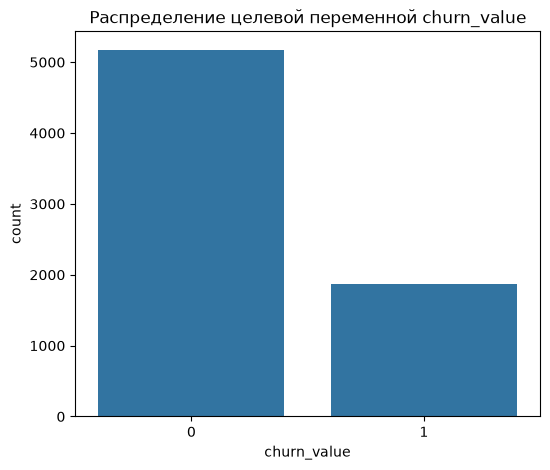

In [259]:
plt.figure(figsize=(6, 5))
sns.countplot(data=data, x='churn_value')
plt.title('Распределение целевой переменной churn_value')
plt.show()

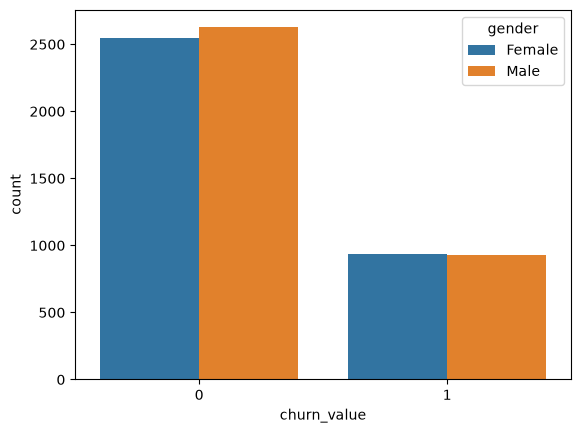

In [260]:
sns.countplot(x=data['churn_value'], hue=data['gender'])
plt.show()

По графику заметим, что пол не влияет на целевую переменную.

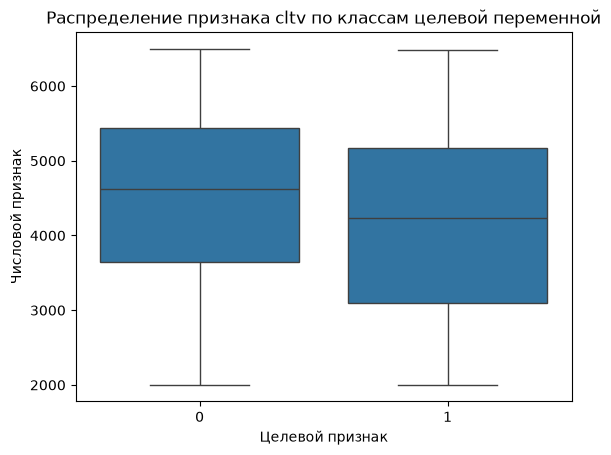

In [261]:
sns.boxplot(x='churn_value', y='cltv', data=data)
plt.title('Распределение признака cltv по классам целевой переменной')
plt.xlabel('Целевой признак')
plt.ylabel('Числовой признак')
plt.show()

CLTV (Customer Lifetime Value) — это маркетинговая метрика, определяющая чистую прибыль от одного клиента за весь период взаимодействия с компанией.

### Расмотрим категориальные признаки

In [262]:
print(data['country'].nunique())
print(data['state'].nunique())

1
1


In [263]:
data['city'].unique()

<StringArray>
[    'Los Angeles',   'Beverly Hills', 'Huntington Park',         'Lynwood',
  'Marina Del Rey',       'Inglewood',    'Santa Monica',        'Torrance',
        'Whittier',        'La Habra',
 ...
      'Janesville',      'Litchfield',        'Loyalton',        'Madeline',
    'Markleeville',         'Milford',         'Calpine',        'Standish',
        'Tulelake',  'Olympic Valley']
Length: 1129, dtype: str

In [264]:
print(data['gender'].value_counts())
print(data['senior_citizen'].value_counts())
print(data['partner'].value_counts())
print(data['dependents'].value_counts())

gender
Male      3555
Female    3488
Name: count, dtype: int64
senior_citizen
No     5901
Yes    1142
Name: count, dtype: int64
partner
No     3641
Yes    3402
Name: count, dtype: int64
dependents
No     5416
Yes    1627
Name: count, dtype: int64


In [265]:
print(data['phone_service'].value_counts())
print(data['multiple_lines'].value_counts())
print(data['online_security'].value_counts())
print(data['online_backup'].value_counts())

phone_service
Yes    6361
No      682
Name: count, dtype: int64
multiple_lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
online_security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
online_backup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


In [266]:
print(data['device_protection'].value_counts())
print(data['tech_support'].value_counts())
print(data['streaming_tv'].value_counts())
print(data['streaming_movies'].value_counts())
print(data['paperless_billing'].value_counts())

device_protection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
tech_support
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64
streaming_tv
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64
streaming_movies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64
paperless_billing
Yes    4171
No     2872
Name: count, dtype: int64


In [267]:
data['gender'] = data['gender'].map({'Male': 0, 'Female': 1})
data['senior_citizen'] = data['senior_citizen'].map({'No': 0, 'Yes': 1})
data['partner'] = data['partner'].map({'No': 0, 'Yes': 1})
data['dependents'] = data['dependents'].map({'No': 0, 'Yes': 1})
data['phone_service'] = data['phone_service'].map({'No': 0, 'Yes': 1})
data['paperless_billing'] = data['paperless_billing'].map({'No': 0, 'Yes': 1})

data.sample()

,customerid,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,...,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason
5726,5376-PCKNB,1,United States,California,Montclair,91763,"34.072121, -117.698319",34.072121,-117.698319,0,...,One year,1,Credit card (automatic),104.45,7459,No,0,29,4750,NaN


In [268]:
data = data.drop(columns=['country', 'state', 'customerid', 'churn_label', 'count', 'lat_long', 'churn_reason', 'churn_score'])

In [269]:
data[data['total_charges'] == ' ']

,city,zip_code,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,cltv
2234,San Bernardino,92408,34.084909,-117.258107,1,0,1,0,0,0,...,Yes,Yes,No,Two year,1,Bank transfer (automatic),52.55,,0,2578
2438,Independence,93526,36.869584,-118.189241,0,0,0,0,0,1,...,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.25,,0,5504
2568,San Mateo,94401,37.590421,-122.306467,1,0,1,0,0,1,...,No,Yes,Yes,Two year,0,Mailed check,80.85,,0,2048
2667,Cupertino,95014,37.306612,-122.080621,0,0,1,1,0,1,...,No internet service,No internet service,No internet service,Two year,0,Mailed check,25.75,,0,4950
2856,Redcrest,95569,40.363446,-123.835041,1,0,1,0,0,0,...,Yes,Yes,No,Two year,0,Credit card (automatic),56.05,,0,4740
4331,Los Angeles,90029,34.089953,-118.294824,0,0,1,1,0,1,...,No internet service,No internet service,No internet service,Two year,0,Mailed check,19.85,,0,2019
4687,Sun City,92585,33.739412,-117.173334,0,0,1,1,0,1,...,No internet service,No internet service,No internet service,Two year,0,Mailed check,25.35,,0,2299
5104,Ben Lomond,95005,37.078873,-122.090386,1,0,1,1,0,1,...,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.00,,0,3763
5719,La Verne,91750,34.144703,-117.770299,0,0,1,1,0,1,...,No internet service,No internet service,No internet service,One year,1,Mailed check,19.70,,0,4890
6772,Bell,90201,33.970343,-118.171368,1,0,1,1,0,1,...,Yes,Yes,No,Two year,0,Mailed check,73.35,,0,2342


In [270]:
data = data[data['total_charges'] != ' ']

In [271]:
data['total_charges'] = data['total_charges'].astype('float32')

#### Feature Engineering

In [272]:
# утечка данных?
encoder = TargetEncoder(smooth=1)
data['city_encoded'] = encoder.fit_transform(data[['city']], data['churn_value'])
data = data.drop(columns=['city'])

In [273]:
data.iloc[:, 19:27].info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   payment_method   7032 non-null   str    
 1   monthly_charges  7032 non-null   float64
 2   total_charges    7032 non-null   float32
 3   churn_value      7032 non-null   int64  
 4   cltv             7032 non-null   int64  
 5   city_encoded     7032 non-null   float64
dtypes: float32(1), float64(2), int64(2), str(1)
memory usage: 357.1 KB


In [281]:
cols = ['zip_code', 'latitude', 'longitude', 'gender', 'senior_citizen', 'partner', 'dependents',
        'tenure_months', 'phone_service', 'paperless_billing', 'monthly_charges', 'total_charges',
        'cltv', 'city_encoded', 'churn_value']
corr_matrix = data[cols].corr()

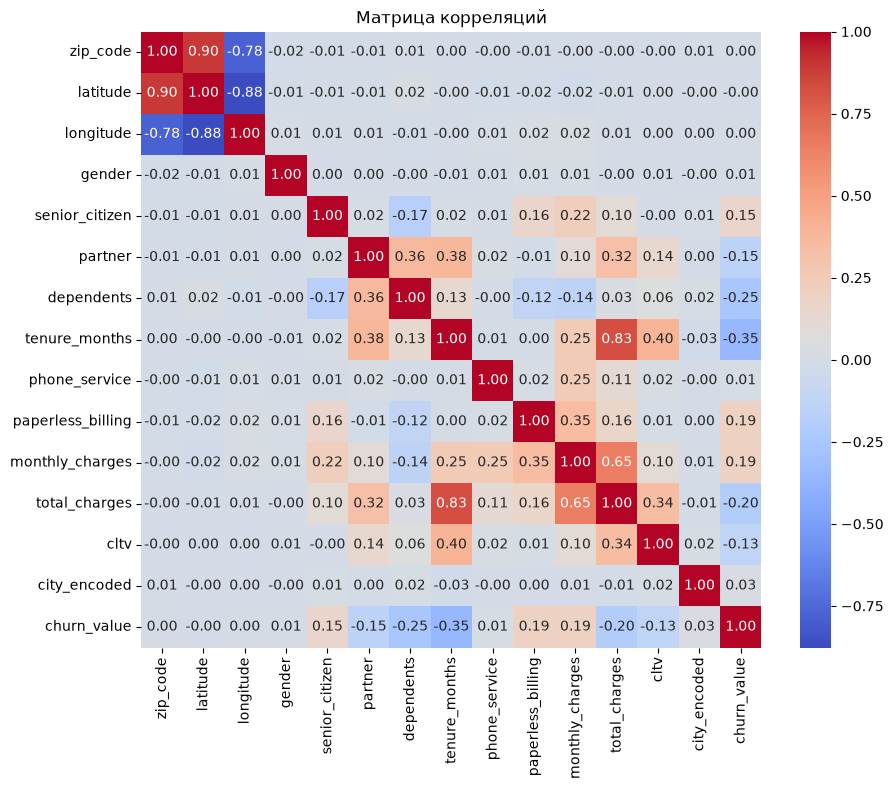

In [282]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

In [ ]:
data = data.drop(columns=['latitude', 'longitude', 'total_charges'])

### Вывод по разведочному анализу данных
- Замечен сильный дисбаланс классов целевой переменной churn_label. Необходимо использовать **сэмплирование** – выравнивание долей классов в обучающей выборке. 
- Удалить несколько признаков: country и state имеют единственное значение, поэтому не несут в себе никакой закономерности. 
- Признак city имеет 1129 уникальных городов, поэтому закодируем его с помощью TargetEncoding. 
- Бинарные признаки (gender, senior citizen, partner, ) закодировали с помощью встроенной фукнции .map().
- Признаки с 3 и более уникальными значениями закодируем с помощью OHE.
- Были найдены пустые значения признака total_charges и впоследствие удалены.
- По матрице корреляций заметим мультиколлинеарность: между latitude и zip_code, latitude и longitude, longitude и zip_code, а также между total_charges и tenure_months. Удалим latitude, longitude и total_charges (так как tenure_months имеет более сильную корреляцию с целевой переменной, чем total_charges). 

## Построение модели

In [ ]:
y = data['churn_value']
X = data.drop(columns=['churn_value'])
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X.select_dtypes(include=['str']).columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='No reason')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', cat_transformer, categorical_cols)
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['zip_code','gender','senior_citizen',...,'monthly_charges','cltv', 'city_encoded']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

In [ ]:

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]


In [ ]:
roc_auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)
print(f'ROC AUC score = {roc_auc:.3f}\nF1 score = {f1:.3f}')

ROC AUC score = 0.842
F1 score = 0.615


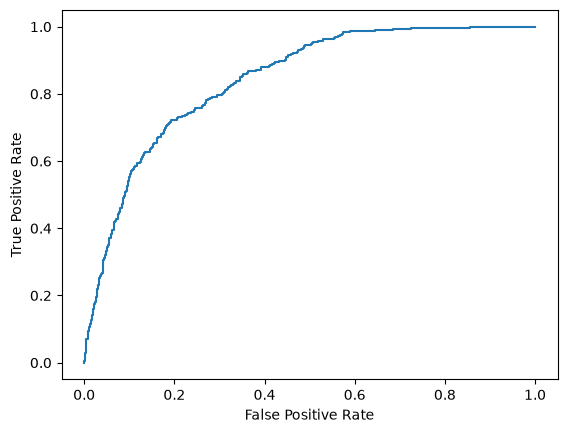

In [276]:
fpr, tpr, _ = roc_curve(y_test,  y_proba)

# построение ROC кривой
plt.plot(fpr, tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

### Результаты Логистической модели
- ROC AUC имеет неплохой результат.
- F1 score имеет средний результат (модель пропускает ложные срабатывания или не видит важных объектов). 

In [ ]:
pipeline_cb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(random_state=42))
])

pipeline_cb.fit(X_train, y_train)

Learning rate set to 0.02154
0:	learn: 0.6753981	total: 59.9ms	remaining: 59.8s
1:	learn: 0.6585068	total: 62.2ms	remaining: 31s
2:	learn: 0.6423968	total: 64.2ms	remaining: 21.3s
3:	learn: 0.6302744	total: 66.2ms	remaining: 16.5s
4:	learn: 0.6199357	total: 68.2ms	remaining: 13.6s
5:	learn: 0.6084873	total: 70.2ms	remaining: 11.6s
6:	learn: 0.5955666	total: 72.1ms	remaining: 10.2s
7:	learn: 0.5854953	total: 74.1ms	remaining: 9.19s
8:	learn: 0.5740592	total: 76.1ms	remaining: 8.37s
9:	learn: 0.5647571	total: 78.1ms	remaining: 7.74s
10:	learn: 0.5561963	total: 80.2ms	remaining: 7.21s
11:	learn: 0.5468184	total: 82.2ms	remaining: 6.76s
12:	learn: 0.5391898	total: 84.3ms	remaining: 6.4s
13:	learn: 0.5308087	total: 86.5ms	remaining: 6.09s
14:	learn: 0.5244283	total: 88.5ms	remaining: 5.81s
15:	learn: 0.5179944	total: 90.4ms	remaining: 5.56s
16:	learn: 0.5108585	total: 92.6ms	remaining: 5.35s
17:	learn: 0.5053059	total: 94.7ms	remaining: 5.17s
18:	learn: 0.5003455	total: 96.9ms	remaining: 5s

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['zip_code','gender','senior_citizen',...,'monthly_charges','cltv', 'city_encoded']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

In [ ]:
y_pred_rf = pipeline_cb.predict(X_test)
y_proba_rf = pipeline_cb.predict_proba(X_test)[:, 1]

print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}')
print(f'F1: {f1_score(y_test, y_pred_rf):.3f}')

ROC-AUC: 0.850
F1: 0.592
